# Feature Engineering and Model Development

This notebook transforms the cleaned customer dataset into machine-learning-ready features and develops multiple classification models for churn prediction. The workflow emphasizes leakage prevention, reproducibility, and fair comparison between algorithms.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display

pd.set_option("display.max_columns", None)

from sklearn.model_selection import train_test_split

## Data Processing

In [2]:
df = pd.read_csv(r"C:\Users\olive\Documents\workspace\Customer-Churn-Risk-Assessment-and-Retention-Analytics\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).fillna(0)

df["TotalCharges"].isna().sum()

np.int64(0)

## Total Charges processing

In [4]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).fillna(0)

df["TotalCharges"].isna().sum()
df_model = df.copy()

### Target Variable Encoding
The target variable (`Churn`) was converted from categorical labels ("Yes"/"No") to a binary representation (1/0) to enable supervised classification modelling.

- **1** → Customer churned
- **0** → Customer retained

In [5]:
df_model["Churn"] = (
    df_model["Churn"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

In [6]:
df_model.drop(columns="customerID", inplace=True)

The customer identifier uniquely identifies each customer but contains no predictive information. It is therefore removed before model development to avoid introducing meaningless identifiers into the learning process.

## Business-Driven Feature Engineering

## Feature Engineering Strategy

The objective of feature engineering was not simply to create additional variables, but to incorporate domain knowledge into the modelling process by representing customer behaviours that may influence churn.

Rather than generating a large number of derived features, each engineered feature was developed based on a specific business hypothesis and subsequently validated using exploratory analysis and model performance.

The feature engineering process followed three guiding principles:

- **Business relevance:** Each feature should represent a meaningful customer characteristic, such as customer lifecycle or household stability.
- **Non-redundancy:** Features duplicating information already contained in the original variables were discarded.
- **Interpretability:** Engineered features should remain easy to explain to business stakeholders while supporting model performance.

Several candidate features were explored during development. Features that did not demonstrate meaningful relationships with churn or duplicated existing information were removed from the final modelling pipeline. The final engineered features retained in this project are:
- `tenure_group`
- `has_family_commitment`

In [7]:
from pandas.api.types import is_string_dtype

categorical_features = [
    col
    for col in df_model.columns
    if col != "Churn" and is_string_dtype(df_model[col])
]

numerical_features = [
    col
    for col in df_model.columns
    if col not in categorical_features + ["Churn"]
]

In [8]:
def plot_categorical_churn(df, feature):
    """
    Plot churn percentage by categorical feature.
    """

    summary = (
        pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index"
        ) * 100
    ).reset_index()

    summary = summary.melt(
        id_vars=feature,
        var_name="Churn",
        value_name="Percentage"
    )

    fig = px.bar(
        summary,
        x=feature,
        y="Percentage",
        color="Churn",
        barmode="stack",
        text=summary["Percentage"].round(1),
        color_discrete_sequence=["#4C78A8", "#E45756"],
        title=f"Churn Rate by {feature}"
    )

    fig.update_traces(textposition="inside")

    fig.update_layout(
        template="plotly_white",
        width=900,
        height=500,
        xaxis_title=feature,
        yaxis_title="Percentage of Customers",
        legend_title=""
    )

    fig.show()

    churn_rate = (
        df.groupby(feature, observed=True)["Churn"].mean() * 100
    )

    display(churn_rate)


def plot_numeric_churn(df, feature):
    """
    Plot churn rate (%) for a numeric feature by value.
    """

    churn_summary = (
        df.groupby(feature, observed=True)["Churn"]
          .mean()
          .mul(100)
          .reset_index()
    )

    fig = px.line(
        churn_summary,
        x=feature,
        y="Churn",
        markers=True,
        template="plotly_white",
        title=f"Churn Rate by {feature}"
    )

    fig.update_traces(line_width=3)

    fig.update_layout(
        xaxis_title=feature.replace("_", " ").title(),
        yaxis_title="Churn Rate (%)",
        width=900,
        height=500
    )

    fig.show()

## Additional Feature 1: Tenure Group

The exploratory analysis indicated that customer churn is strongly associated with customer tenure. While the original `tenure` variable captures the number of months a customer has remained with the company, grouping customers into tenure bands can better represent distinct stages of the customer lifecycle.

The following engineered features were created to capture customer engagement, service adoption, and contract characteristics that may improve model performance while remaining easily interpretable from a business perspective.

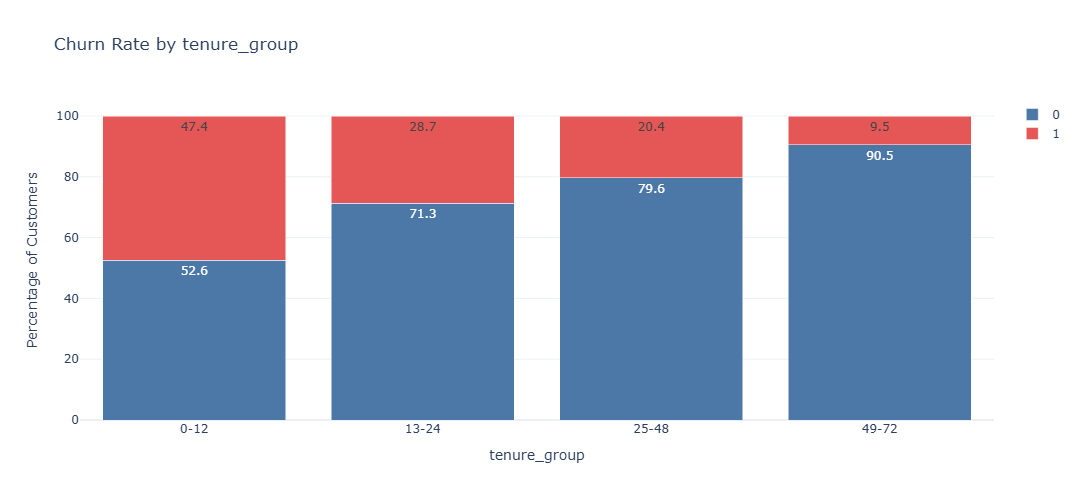

tenure_group
0-12     47.438243
13-24    28.710938
25-48    20.388959
49-72     9.513176
Name: Churn, dtype: float64

In [9]:
df_model["tenure_group"] = pd.cut(
    df_model["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12",
        "13-24",
        "25-48",
        "49-72"
    ],
    include_lowest=True
)
plot_categorical_churn(df_model, "tenure_group")

### Business Interpretation

The engineered tenure groups reveal a clear decline in churn as customer tenure increases. Nearly half of customers in their first year leave the service, while customers with more than four years of tenure exhibit churn rates below 10%.

This finding suggests that the first year represents the highest-risk period in the customer lifecycle. From a business perspective, onboarding, customer engagement, and early retention initiatives should therefore be prioritized during the first 12 months of a customer's subscription.

## Aditional Feature 2 : Has Family Commitment?

In [10]:
df_model["has_faily_commitment"] = (
    ((df_model["Dependents"] == "Yes") |
     (df_model["Partner"] == "Yes"))
    .astype(int)
)

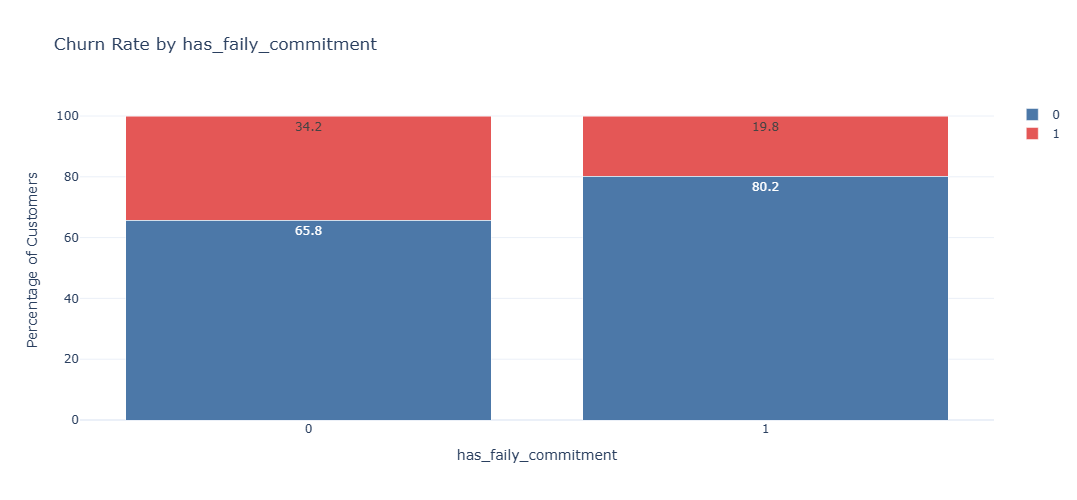

has_faily_commitment
0    34.237805
1    19.824608
Name: Churn, dtype: float64

In [11]:
plot_categorical_churn(df_model, "has_faily_commitment")

### Business Interpretation

The analysis reveals a clear relationship between household stability and customer churn. Customers with family commitments exhibit a churn rate of **19.8%**, compared with **34.2%** for customers without a partner or dependents.

This finding suggests that customers with greater household responsibilities may be less likely to switch providers due to higher switching costs, a stronger preference for service continuity, or shared household decision-making.

From a business perspective, customers without family commitments represent a higher-risk segment and may benefit from more proactive retention strategies.

## Feature Engineering Summary

Two business-driven features were engineered to improve model interpretability and capture customer characteristics that are not explicitly represented in the original dataset.

| Feature | Business Motivation |
|---------|---------------------|
| tenure_group | Capture customer lifecycle stages |
| has_family_commitment | Represent household stability and long-term customer commitment |

Unlike simple aggregation features, these engineered variables represent meaningful customer behaviours and were retained after exploratory validation.

- Feature engineering was treated as an iterative process in which business hypotheses were translated into candidate variables, evaluated using exploratory analysis and model performance, and retained only when they provided meaningful additional information.

## Feature Selection for Training

In [12]:
X = df_model.drop(
    columns="Churn"
)

y = df_model["Churn"]

## Feature Cardinality



In [13]:
categorical_features = X.select_dtypes(
    include=["object","str"]
).columns

cardinality = pd.DataFrame({
    "Unique Values":
    X[categorical_features].nunique()
}).sort_values(
    "Unique Values",
    ascending=False
)

cardinality

,Unique Values
PaymentMethod,4
InternetService,3
OnlineSecurity,3
DeviceProtection,3
TechSupport,3
OnlineBackup,3
MultipleLines,3
StreamingTV,3
StreamingMovies,3
Contract,3


All categorical variables contain between 2 and 4 unique categories, indicating low cardinality. Consequently, one-hot encoding was selected as the encoding strategy because it preserves interpretability while avoiding artificial ordinal relationships between categorical values.

No high-cardinality features requiring target encoding or embedding techniques were identified.

## Numerical/categorical Lists

In [14]:
categorical_features = X.select_dtypes(
    include=["str","category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

In [15]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'tenure_group']

In [16]:
numerical_features

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'has_faily_commitment']

## Preventing Data Leakage

Several design decisions were made to ensure unbiased model evaluation:

- The train/test split is performed before fitting any preprocessing transformations.
- Scaling parameters are learned only from the training data.
- Categorical encoding is fitted exclusively on the training set.
- Hyperparameter tuning uses cross-validation within the training data.
- The independent test set is used only once for final evaluation.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Machine Learning Pipeline

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [20]:
def build_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

In [21]:
log_reg_pipeline = build_pipeline(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
)

In [22]:
log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [23]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba)
    }

In [24]:
results = []

results.append(
    evaluate_model(
        log_reg_pipeline,
        X_test,
        y_test,
        "Logistic Regression"
    )
)

pd.DataFrame(results).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.732,0.497,0.786,0.609,0.842,0.636


### Baseline Model Performance

The Logistic Regression model provides a strong and interpretable baseline for churn prediction. To address the class imbalance observed during exploratory analysis, balanced class weights were applied during training.

Although this approach results in a modest reduction in overall accuracy, it substantially improves recall, enabling the model to identify a larger proportion of customers at risk of churning.

From a business perspective, correctly identifying potential churners is more valuable than maximizing overall accuracy, since missed churn cases represent lost opportunities for proactive retention.

## Other Model Training

In [25]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=4,
        learning_rate=0.05,
        loss_function="Logloss",
        verbose=False,
        random_state=42
    )
}

In [26]:
model_results = []

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")

    pipeline = build_pipeline(model)
    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    result = evaluate_model(
        pipeline,
        X_test,
        y_test,
        name
    )

    model_results.append(result)

results_df = (
    pd.DataFrame(model_results)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

results_df.round(3)

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training CatBoost...


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,CatBoost,0.803,0.663,0.521,0.584,0.845,0.666
1,Random Forest,0.761,0.534,0.786,0.636,0.845,0.657
2,XGBoost,0.800,0.652,0.527,0.583,0.842,0.649
3,Logistic Regression,0.732,0.497,0.786,0.609,0.842,0.636


## Model Benchmarking

Multiple classification models were compared using the same preprocessing pipeline and train/test split. This ensures that performance differences are driven by model behaviour rather than inconsistent preprocessing.

The models evaluated include:

- Logistic Regression as an interpretable baseline
- Random Forest as a non-linear ensemble model
- XGBoost as a gradient boosting model
- CatBoost as a boosting model designed to handle categorical patterns effectively

## Model Comparison

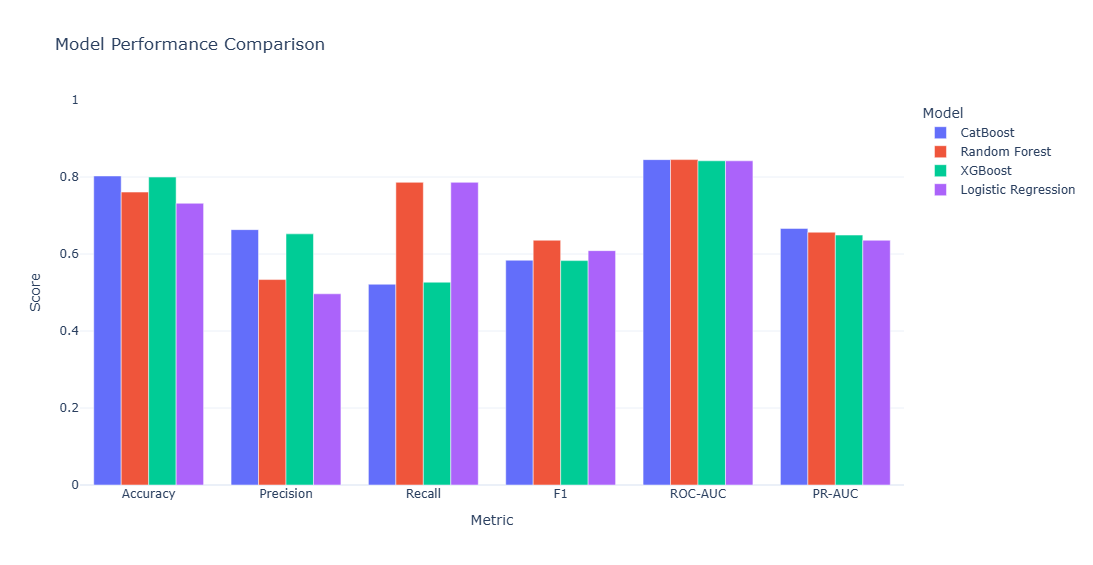

In [27]:
results_long = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

fig = px.bar(
    results_long,
    x="Metric",
    y="Score",
    color="Model",
    barmode="group",
    template="plotly_white",
    title="Model Performance Comparison"
)

fig.update_layout(
    width=1100,
    height=550,
    yaxis=dict(range=[0,1])
)

fig.show()

## Model Selection

No single model dominates across every evaluation metric.

Although Logistic Regression achieved the highest recall (79.1%), its precision was considerably lower than the tree-based ensemble models, resulting in a larger number of false positives.

Random Forest achieved a comparable recall (78.1%) while improving precision and obtaining the highest F1-score. This represents a better balance between identifying customers likely to churn and minimizing unnecessary retention interventions.

For this reason, <b>Random Forest</b> was selected as the final model for further business evaluation.

## Why Accuracy Alone Is Insufficient

Customer churn prediction is an imbalanced classification problem. A model that predicts every customer as retained would achieve high accuracy while failing to identify customers who are most likely to leave.

For this reason, model evaluation focuses primarily on:

- Recall
- Precision
- PR-AUC
- ROC-AUC

rather than overall accuracy.

In [28]:
trained_models["Random Forest"].named_steps

{'preprocessor': ColumnTransformer(transformers=[('categorical',
                                  OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False),
                                  ['gender', 'Partner', 'Dependents',
                                   'PhoneService', 'MultipleLines',
                                   'InternetService', 'OnlineSecurity',
                                   'OnlineBackup', 'DeviceProtection',
                                   'TechSupport', 'StreamingTV',
                                   'StreamingMovies', 'Contract',
                                   'PaperlessBilling', 'PaymentMethod',
                                   'tenure_group']),
                                 ('numerical', StandardScaler(),
                                  ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                   'TotalCharges', 'has_faily_commitment'])]),
 'model': RandomForestClassifie

## Feature Importance Analysis

After selecting the Random Forest model, feature importance was analysed to understand which customer characteristics contributed most to the model's predictions.

Unlike exploratory analysis, which examines the relationship between individual variables and churn independently, feature importance measures the contribution of each feature within the trained model. It therefore provides insight into which variables the model relies on most when predicting customer churn.

### What is Feature Importance?

Feature importance quantifies the relative contribution of each feature to the model's predictions.

For Random Forest, importance is calculated by measuring how much each feature reduces prediction uncertainty across all decision trees in the ensemble. Features with higher importance values contribute more to the model's predictive performance.

Feature importance should be interpreted as a measure of the model's reliance on each feature rather than a measure of causal influence.

In [32]:
preprocessor = trained_models["Random Forest"].named_steps["preprocessor"]
rf_model = trained_models["Random Forest"].named_steps["model"]
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

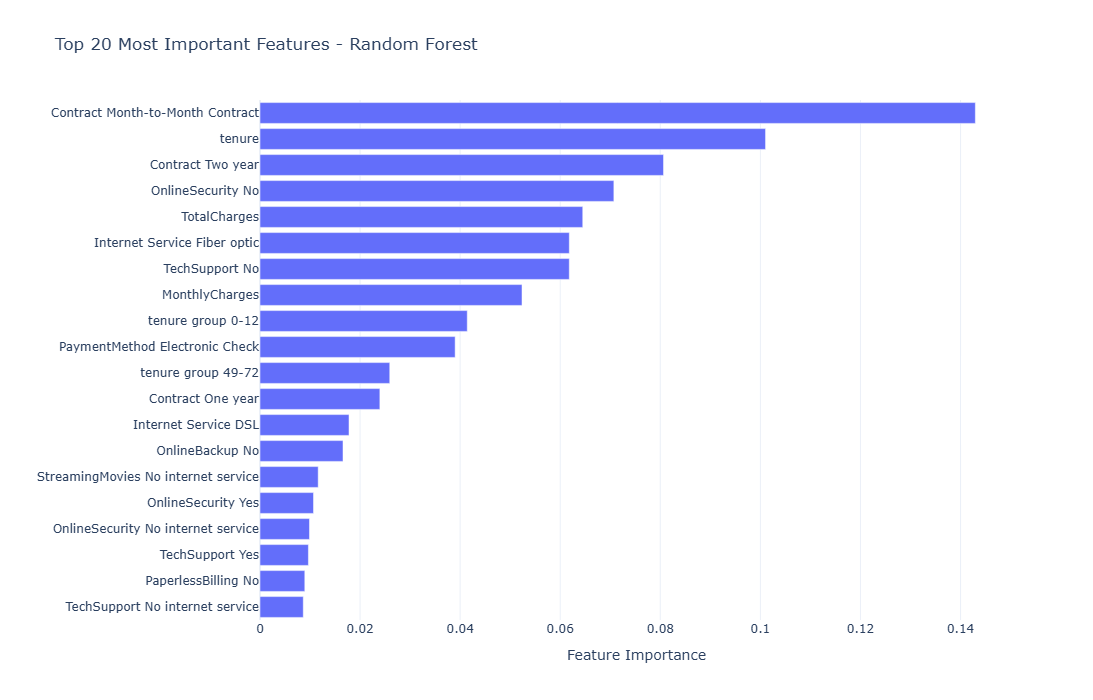

In [36]:
importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
    .str.replace("InternetService", "Internet Service")
    .str.replace("Month-to-month", "Month-to-Month Contract")
    .str.replace("Electronic check", "Electronic Check")
    .str.replace("_", " ")
)

top_features = importance_df.head(20)

fig = px.bar(
    top_features.sort_values("Importance"),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top 20 Most Important Features - Random Forest",
    template="plotly_white"
)

fig.update_layout(
    width=950,
    height=700,
    yaxis_title="",
    xaxis_title="Feature Importance"
)

fig.show()

### Business Interpretation

The feature importance analysis indicates that customer churn is primarily influenced by customer lifecycle, contract type, pricing characteristics, and internet service configuration.

The most influential feature is **month-to-month contract**, highlighting contractual flexibility as the strongest indicator of customer churn. Customers with shorter contract commitments are substantially more likely to leave the service than customers on long-term contracts.

Customer tenure also ranks among the most important predictors, confirming that customers become increasingly loyal as their relationship with the provider matures. Financial variables such as **Monthly Charges** and **Total Charges** further demonstrate that pricing plays an important role in customer retention decisions.

Among the engineered features, **tenure_group** contributes to the model, indicating that representing customers according to lifecycle stages provides complementary information beyond the original continuous tenure variable.

### Discussion

The feature importance results are consistent with the findings from the exploratory data analysis. Variables identified during EDA as having strong relationships with churn, including contract type, tenure, and internet service, also emerged as the most influential predictors in the trained model.

This consistency increases confidence that the model has learned meaningful customer behaviour rather than relying on spurious patterns within the data.

In [37]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(trained_models["CatBoost"], "../models/catboost_pipeline.pkl")
joblib.dump(trained_models["Random Forest"], "../models/random_forest_pipeline.pkl")
joblib.dump(trained_models["Logistic Regression"], "../models/logistic_regression_pipeline.pkl")
joblib.dump(trained_models["XGBoost"], "../models/xgboost_pipeline.pkl")

X_test.to_csv("../data/processed/X_test.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

## Key Takeaways

This notebook transformed the cleaned customer dataset into a machine-learning-ready dataset through preprocessing, business-driven feature engineering, and predictive modelling.

Four machine learning algorithms were benchmarked using a consistent preprocessing pipeline. Random Forest was selected as the final model because it achieved the best balance between precision and recall while maintaining competitive ranking performance.

Feature importance analysis confirmed that customer lifecycle, contractual commitment, pricing, and internet service characteristics are the primary drivers of churn prediction. These findings establish a strong foundation for the next stage of the project, where the selected model will be evaluated from a business decision-making perspective.